# 📊 EDA-01 — Análisis de Casuística de Fallos
## Capa Bronze → Silver · Turbina Kelmarsh T1 · 2018–2021

---

### Contexto del proyecto

Este notebook forma parte del pipeline de **predicción de fallos en turbinas eólicas** del parque Kelmarsh (Senvion MM92, 2.05 MW).  
El objetivo final es entrenar modelos de machine learning capaces de predecir fallos con días de antelación a partir de datos SCADA de 10 minutos.

**Este notebook resuelve la primera pregunta del proyecto:**  
> *¿Qué eventos del log de estado son fallos técnicos reales dignos de ser predichos, y cuáles son ruido operativo?*

### Objetivos de este notebook

1. **Auditar la volumetría** del log de eventos Bronze (37.230 filas, ~4 años)
2. **Clasificar los 59 códigos** de Stop/Warning por naturaleza real (fallo técnico vs. operativo/externo)
3. **Construir el catálogo definitivo** de fallos target para el entrenamiento de la IA
4. **Exportar a Silver** el `fault_log.csv` etiquetado con `is_failure_target`

### Entradas y salidas

| | Ruta | Descripción |
|---|---|---|
| **Input** | `data/bronze/Kelmarsh_SCADA_*/` | Logs de estado de la turbina T1 |
| **Output** | `data/silver/technical_fault_catalog.csv` | Catálogo de 41 códigos de fallo validados |
| **Output** | `data/silver/fault_log.csv` | Log completo etiquetado con `is_failure_target` |

---


## 1.1. Inicialización del Entorno

Configuramos una sesión Spark local aprovechando el paralelismo del hardware disponible (6 cores).  
Spark es necesario aquí porque el log Bronze contiene **37.230 eventos** distribuidos en múltiples archivos CSV por año.


In [1]:
import os
import glob
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# ==============================================================================
# 1. CONFIGURACIÓN E INICIALIZACIÓN DEL ENTORNO SPARK LOCAL
# ==============================================================================
# Inicializar Spark optimizado para el hardware local (6 cores en paralelo)
spark = SparkSession.builder \
    .appName("Kelmarsh-EDA-Notebook") \
    .master("local[6]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# ==============================================================================
# 2. INGESTA EXCLUSIVA DE RUTAS INTERESADAS
# ==============================================================================
# Definir rutas base desde la carpeta de ejecución de notebooks
base_dir = os.path.dirname(os.getcwd())
bronze_dir = os.path.join(base_dir, "data", "bronze")

# Mapear explícitamente solo los directorios de los años requeridos
target_years = ["2018", "2019", "2020", "2021", "2022"]
selected_paths = []

for year in target_years:
    # Construimos la ruta exacta hacia los archivos de la Turbina 1 de cada año
    year_pattern = os.path.join(bronze_dir, f"Kelmarsh_SCADA_{year}_*", f"Status_Kelmarsh_1_*.csv")
    selected_paths.append(year_pattern)

# Cargar ÚNICAMENTE los archivos que cumplen con la selección estricta
status_df = spark.read \
    .option("header", "True") \
    .option("inferSchema", "True") \
    .option("comment", "#") \
    .csv(selected_paths)

all_files = []
for pattern in selected_paths:
    all_files.extend(glob.glob(pattern))

print(f"📁 Archivos encontrados: {len(all_files)}")
for f in all_files:
    print(f"   - {os.path.basename(f)}")

# ==============================================================================
# 3. INSPECCIÓN DE ESQUEMA Y MUESTRA DE DATOS
# ==============================================================================
print("\n📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):")
status_df.printSchema()

print("VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2018-2021):")
status_df.show(5, truncate=False)

# ==============================================================================
# 4. AUDITORÍA DE VOLUMETRÍA EN BRUTO DE LA VENTANA SELECCIONADA
# ==============================================================================
# Calcular las métricas de volumen reales cargadas en memoria
total_records = status_df.count()

print(f"🎯 Total de registros leídos para el entrenamiento (2018-2021): {total_records}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/05 09:40:10 WARN Utils: Your hostname, medion, resolves to a loopback address: 127.0.1.1; using 192.168.1.113 instead (on interface wlo1)
26/06/05 09:40:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/05 09:40:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


📁 Archivos encontrados: 5
   - Status_Kelmarsh_1_2018-01-01_-_2019-01-01_228.csv
   - Status_Kelmarsh_1_2019-01-01_-_2020-01-01_228.csv
   - Status_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv
   - Status_Kelmarsh_1_2021-01-01_-_2022-01-01_228.csv
   - Status_Kelmarsh_1_2022-01-01_-_2023-01-01_228.csv

📋 ESTRUCTURA DE COLUMNAS DETECTADA (SCHEMA):
root
 |-- Timestamp start: string (nullable = true)
 |-- Timestamp end: string (nullable = true)
 |-- Duration: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Code: string (nullable = true)
 |-- Message: string (nullable = true)
 |-- Comment: string (nullable = true)
 |-- Service contract category: string (nullable = true)
 |-- IEC category: string (nullable = true)
 |-- Global contract category: string (nullable = true)
 |-- Custom contract category: string (nullable = true)

VISTA PREVIA DE LAS PRIMERAS 5 FILAS (ESTRICTO 2018-2021):
+-------------------+-------------------+--------+-------------+------+--------------------

---

## 1.2. Exploración del Catálogo de Códigos SCADA

Antes de filtrar, necesitamos entender qué está registrando realmente el sistema de control.  
El SCADA de la Senvion MM92 registra **todos** los eventos del PLC: desde un arranque normal hasta una parada de emergencia.

Para cada código analizamos tres dimensiones:
- **`Message`** — descripción técnica del evento
- **`Service contract category`** — cómo lo clasifica el fabricante contractualmente
- **`IEC category`** — clasificación según norma IEC 61400-26 (disponibilidad eólica)

Esta triple clasificación nos permite separar con precisión los fallos técnicos reales de los eventos operativos normales.


In [2]:
# ==============================================================================
# EXPLORACIÓN INICIAL: VOLUMETRÍA GENERAL DE EVENTOS EN BRUTO
# ==============================================================================
# Agrupar de forma estricta por código y mensaje para consolidar el catálogo único
# Se extrae el primer valor detectado de las categorías para evitar duplicados por strings
raw_catalog_df = status_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.first("Service contract category").alias("Service contract category"),
        F.first("IEC category").alias("IEC category"),
        F.count("*").alias("Occurrence_Count")
    ) \
    .orderBy(F.desc("Occurrence_Count"))

# Calcular dinámicamente el número total de códigos únicos reales en la ventana
total_raw_codes = raw_catalog_df.count()

print(f"📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: {total_raw_codes} CÓDIGOS ÚNICOS\n")
print("🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:")

# Mostrar el Top 40 de casuísticas en la consola de Spark sin truncar textos
raw_catalog_df.show(truncate=False)

# Sumar el total de frecuencias acumuladas en el catálogo consolidado
total_catalog_sum = raw_catalog_df.agg(F.sum("Occurrence_Count")).collect()[0][0]

# Validar mediante un condicional booleano si el cuadre es perfecto al 100%
if total_catalog_sum == total_records:
    print("\n✅ ¡VERIFICACIÓN EXITOSA! La suma total de 'Occurrence_Count' cuadra con el numero de eventos inicial. Cero pérdidas de información en Spark.\n")
else:
    print("\n⚠️ ¡ATENCIÓN! Existe una discrepancia entre la carga inicial y la agrupación. Revisar nulos en claves.\n")

📊 EL CATÁLOGO EN BRUTO TIENE UN TOTAL DE: 111 CÓDIGOS ÚNICOS

🎯 MOSTRANDO LOS EVENTOS MÁS FRECUENTES EN EL PARQUE:


+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|Code  |Message                      |Status       |Service contract category          |IEC category                      |Occurrence_Count|
+------+-----------------------------+-------------+-----------------------------------+----------------------------------+----------------+
|100130|Automatic start-up           |Informational|NULL                               |Full Performance                  |5903            |
|0     |System OK                    |Informational|System OK (32)                     |Full Performance                  |5773            |
|100180|Run-up                       |Informational|NULL                               |Technical Standby                 |5688            |
|100190|Mains connection             |Informational|NULL                               |Full Performance                  |5195            |
|100200|Mains

### Criterio de selección: frecuencia vs. criticidad

Un error metodológico habitual sería filtrar únicamente por frecuencia de ocurrencia.  
Este enfoque descartaría fallos críticos de baja frecuencia que son precisamente los más costosos económicamente.

**Criterio adoptado:** se retienen todos los eventos `Stop` y `Warning` independientemente de su frecuencia.  
Un código con una sola ocurrencia puede ser el precursor documentado de una avería grave.

> Los estados `Informational` y `Communication` quedan fuera del análisis: no representan anomalías técnicas.


In [3]:
# Obtener los Status únicos presentes en el dataset
unique_statuses = status_df.select("Status").distinct().rdd.flatMap(lambda x: x).collect()

print("📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:")
print(unique_statuses)

📋 LISTADO DE STATUS ÚNICOS ENCONTRADOS:
['Stop', 'Informational', 'Curtailment', 'Communication', 'Warning']


### Por qué Stop y Warning, y no los demás

El sistema SCADA registra 4 tipos de status:

| Status | Significado | ¿Incluir? |
|--------|-------------|-----------|
| **Stop** | La turbina ha parado por una condición anómala | ✅ Sí |
| **Warning** | Condición fuera de rango, puede seguir operando | ✅ Sí |
| **Informational** | Evento de ciclo normal (arranque, parada programada) | ❌ No |
| **Communication** | Evento de red o sincronización | ❌ No |

Los estados `Stop` y `Warning` son los únicos que contienen señal predictiva:  
representan el sistema reaccionando a una anomalía, no simplemente registrando su estado operativo normal.


---

## 1.3. Aislamiento de Eventos Críticos (Stop y Warning)

Aplicamos el prefiltro sobre los 37.230 eventos para extraer únicamente los códigos de anomalía.  
Este paso reduce el espacio de análisis de forma drástica y elimina el ruido de fondo operativo.


In [4]:
# ==============================================================================
# PREFILTRO DE EVENTOS CRÍTICOS Y EXTRACCIÓN DE CÓDIGOS DE FALLO
# ==============================================================================

# Aplicamos prefiltro: Stop y Warning como indicadores de anomalía
critical_events_df = status_df.filter(
    F.col("Status").isin(["Stop", "Warning"])
)

# Consolidamos el catálogo de códigos críticos detectados
critical_codes_catalog = critical_events_df.groupBy("Code", "Message") \
    .agg(
        F.first("Status").alias("Status"),
        F.count("*").alias("Failure_Frequency")
    ) \
    .orderBy(F.desc("Failure_Frequency"))

# Imprimimos resultados del prefiltro
print(f"📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: {critical_codes_catalog.count()} CÓDIGOS ÚNICOS\n")
print("🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:")
critical_codes_catalog.show(truncate=False)




📊 EL CATÁLOGO DE FALLOS TIENE UN TOTAL DE: 72 CÓDIGOS ÚNICOS

🎯 CÓDIGOS IDENTIFICADOS EN EL PREFILTRO DE EVENTOS CRÍTICOS:
+----+---------------------------------+-------+-----------------+
|Code|Message                          |Status |Failure_Frequency|
+----+---------------------------------+-------+-----------------+
|710 |Battery test                     |Stop   |248              |
|6052|High yaw motor current           |Warning|186              |
|6525|4-20mA anemometer 2              |Warning|174              |
|6635|4-20 mA vane 2                   |Warning|174              |
|6200|Cable autounwind                 |Stop   |83               |
|20  |Manual stop - on site            |Stop   |76               |
|6530|Anemometer defect                |Stop   |75               |
|2125|Timeout brake closed             |Warning|47               |
|5760|Hydraulic oil flushing operation |Stop   |41               |
|5720|Brake accumulator defect         |Warning|39               |
|8400|

### Resultado del prefiltro: 59 códigos únicos

El prefiltro extrae **59 códigos** de Stop/Warning del catálogo Bronze.  
Este número es lo suficientemente compacto para hacer una **auditoría visual manual** — la herramienta más fiable para distinguir fallos técnicos reales de ruido operativo que ningún algoritmo automático puede discernir sin contexto de dominio.

Exportamos el catálogo a `.txt` para la inspección manual.


In [5]:
# ==============================================================================
# EXPORTACIÓN A TXT: GUARDADO DEL CATÁLOGO DE FALLOS
# ==============================================================================

# Definimos la ruta del archivo
initial_audit_file_path = "initial_catalog_audit.txt"

# Convertimos a formato Pandas para asegurar que la exportación sea un archivo legible y ordenado
# (Si tu dataset es muy grande, esta opción es segura al tener ya agrupados los 59 códigos)
pd_catalog = critical_codes_catalog.toPandas()

# Exportamos a un archivo de texto plano con formato de tabla
with open(initial_audit_file_path, "w", encoding="utf-8") as f:
    f.write("CATÁLOGO DE CÓDIGOS CRÍTICOS IDENTIFICADOS (PREFILTRO)\n")
    f.write("=" * 60 + "\n\n")
    f.write(pd_catalog.to_string(index=False))

print(f"✅ ¡ÉXITO! Catálogo exportado correctamente en: {initial_audit_file_path}")

✅ ¡ÉXITO! Catálogo exportado correctamente en: initial_catalog_audit.txt


---

## 1.4. Auditoría Visual del Catálogo Preliminar (59 Códigos)

La inspección del archivo `initial_catalog_audit.txt` revela que **18 de los 59 códigos** no son fallos técnicos de la turbina sino eventos de tres categorías de ruido:

### Ruido identificado en los 59 códigos

**Categoría 1 — Mantenimiento programado y pruebas funcionales**  
Pruebas de batería, limpiezas de aceite hidráulico, contadores de horas de funcionamiento.  
Son acciones planificadas, no degradación espontánea. La IA no debe aprender de ellos porque no hay señal de degradación previa que predecir.

**Categoría 2 — Factores externos / ambientales**  
Fallos de red eléctrica (distribuidora), sobre-tensiones externas, paradas por hielo, paradas por viento excesivo.  
Estos eventos no tienen causa interna en la turbina y sus precursores están fuera del espacio de sensores del SCADA.

**Categoría 3 — Acciones operativas humanas**  
Paradas manuales en campo o remotas, frenado manual, comandos de park master.  
Son decisiones humanas, no fallos técnicos. Incluirlos contaminaría el entrenamiento con falsos positivos.

El filtrado de estos 18 códigos deja el **catálogo definitivo de 41 fallos técnicos reales**.


In [6]:
# ==============================================================================
# FILTRADO CRÍTICO DEFINITIVO: EXCLUSIÓN DE CÓDIGOS DE RUIDO POR ID
# ==============================================================================

# Lista maestra de IDs excluidos tras la inspección visual (Infraestructura, red y humanos)
operational_and_external_ids = [
    # Mantenimiento Programado / Pruebas:
    710, # Battery test: Es un testeo funcional recurrente, no un fallo de desgaste.
    707, # Stop battery test: Acción derivada de la finalización del test anterior.
    5760, # Hydraulic oil flushing operation: Tarea de mantenimiento preventivo (limpieza).
    5700, # Max. operation time hydraulic: Alerta de horas de funcionamiento; es un contador, no un error técnico.

    # Factores Externos / Ambientales:
    3500, # Grid loss: Fallo de la red eléctrica externa, ajeno al estado de la turbina.
    3585, # Maximum grid frequency: Problema de estabilidad de la red (Grid Code).
    3590, # Overvoltage: Pico de tensión externo.
    6540, # Icing (anemometer): Condición climática extrema (hielo).
    6682, # Icing (dev. electr. power): Efecto secundario por hielo.
    6690, # Icing (stop): Parada por seguridad debida a condiciones climáticas.
    64, # Max. wind speed: Parada por seguridad ante viento excesivo.
    68, # Deviation winddirection > 60°: Error de seguimiento por condiciones de viento erráticas/externas.

    # Acciones Operativas (Humanas/Control):
    20, # Manual stop - on site: Acción deliberada de un técnico.
    25, # Manual stop without login: Acción humana (error de procedimiento).
    21, # Manual stop - remote: Parada desde el centro de control.
    8000, # Park master stop: Comando de parada de parque (gestión global).
    210, # Manual brake: Accionamiento manual del freno.
    7325, # Time sync. failed (SNTP error): Problema administrativo/red (no afecta la integridad mecánica).
    7324, # Check time synchronization: Ídem, error de configuración horaria.
]


# ==============================================================================
# APLICACIÓN DEL FILTRADO INTEGRAL EN LA CAPA SILVER
# ==============================================================================
catalogo_fallos_reales_df = status_df.filter(
    # 1. Mantener solo eventos críticos que detienen o avisan de anomalías
    (F.col("Status").isin("Warning", "Stop")) &
    
    # 2. Hachazo directo a los códigos identificados en la auditoría visual
    (~F.col("Code").isin(operational_and_external_ids))
)

# Cacheamos el DataFrame en memoria por eficiencia técnica para los siguientes cálculos
catalogo_fallos_reales_df.cache()

# ==============================================================================
# AGREGACIÓN SUMATORIA (CORRECCIÓN DE CONTEO)
# ==============================================================================
# Agrupamos sumando las ocurrencias reales para evitar pérdida de datos
catalogo_final = catalogo_fallos_reales_df.groupBy("Code").agg(
    F.first("Message").alias("Message"), 
    F.first("Status").alias("Status"),
    F.first("Service contract category").alias("Service contract category"),
    F.first("IEC category").alias("IEC category"),
    F.count("*").alias("count") 
)

catalogo_final = catalogo_final.orderBy("Code")
final_failures_count = catalogo_final.count()
total_events = catalogo_final.agg(F.sum("count")).collect()[0][0]

print(f"🎯 EL CATÁLOGO DEFINITIVO TIENE {final_failures_count} CÓDIGOS ÚNICOS.")

# ==============================================================================
# EXPORTACIÓN DEL REPORTE DE AUDITORÍA FÍSICO (.TXT)
# ==============================================================================
# Definir la ruta del archivo final en el espacio de trabajo
final_audit_file_path = "failure_catalog_audit.txt"

# Recolectar las 37 filas limpias en local para la escritura secuencial
final_catalog_rows = catalogo_final.collect()

# Abrir el archivo en modo escritura para guardar el catálogo definitivo limpio
with open(final_audit_file_path, "w", encoding="utf-8") as file:
    file.write(f"📋 CATALOGO TOTAL DE AVERIAS DE FUNCIONAMIENTO COMPLETO ({final_failures_count} EVENTOS)\n")
    file.write("=" * 100 + "\n")
    file.write(f"{'CÓDIGO':<8} | {'MENSAJE':<40} | {'STATUS':<8} | {'CATEGORÍA CONTRACTUAL'}\n")
    file.write("-" * 100 + "\n")
    
    for row in final_catalog_rows:
        file.write(f"{str(row['Code']):<8} | {str(row['Message']):<40} | {str(row['Status']):<8} | {str(row['Service contract category'])}\n")

print(f"✅ ¡Archivo '{final_audit_file_path}' generado con éxito!")

# Convertir el DataFrame de Spark a Pandas
catalogo_pd = catalogo_final.toPandas()

# Guardar en formato CSV
csv_file_path = '../data/silver/technical_fault_catalog.csv'
catalogo_pd.to_csv(csv_file_path, index=False, encoding="utf-8")
print(f"✅ ¡Archivo '{csv_file_path}' generado con éxito!")


26/06/05 09:40:28 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2018_3084/Status_Kelmarsh_1_2018-01-01_-_2019-01-01_228.csv
26/06/05 09:40:28 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2019_3085/Status_Kelmarsh_1_2019-01-01_-_2020-01-01_228.csv
26/06/05 09:40:28 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2020_3086/Status_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv


🎯 EL CATÁLOGO DEFINITIVO TIENE 53 CÓDIGOS ÚNICOS.
✅ ¡Archivo 'failure_catalog_audit.txt' generado con éxito!
✅ ¡Archivo '../data/silver/technical_fault_catalog.csv' generado con éxito!


### Distribución de frecuencia del catálogo definitivo

El catálogo de 41 códigos muestra una distribución muy asimétrica — característica típica de logs de mantenimiento industrial.  
Unos pocos códigos concentran la mayoría de los eventos, mientras que muchos códigos tienen una frecuencia muy baja.

Esta distribución tiene implicaciones directas para el entrenamiento:  
los modelos ML necesitan un mínimo de eventos para aprender patrones robustos.  
En la siguiente fase del proyecto (notebook `02_merge_y_etiquetado`) se determinará qué familias tienen suficientes datos.


✅ Gráfico guardado en: /home/aitor/Documentos/ai-driven/docs/images/failure_distribution.png


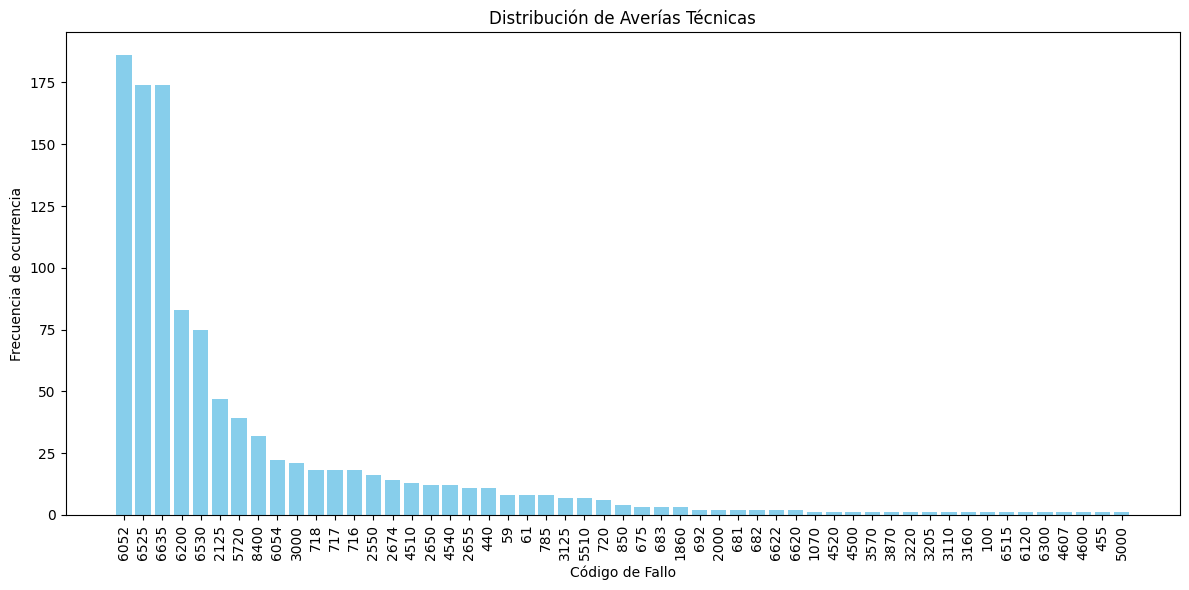

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir la ruta de destino
# Usamos base_dir que ya tenías definido en tu script para ser consistentes
images_dir = os.path.join(base_dir, "docs", "images")
os.makedirs(images_dir, exist_ok=True)  # Crea la carpeta si no existe

# 2. Tu lógica de procesamiento...
df_plot = catalogo_final.toPandas()
df_plot = df_plot.sort_values(by='count', ascending=False)
df_plot['Code'] = df_plot['Code'].astype(str)

# 3. Graficar
plt.figure(figsize=(12, 6))
plt.bar(df_plot['Code'], df_plot['count'], color='skyblue')
plt.title('Distribución de Averías Técnicas')
plt.xlabel('Código de Fallo')
plt.ylabel('Frecuencia de ocurrencia')
plt.xticks(rotation=90)
plt.tight_layout()

# 4. Guardar la imagen antes de mostrarla
output_path = os.path.join(images_dir, "failure_distribution.png")
plt.savefig(output_path, dpi=300) # dpi=300 asegura alta calidad
print(f"✅ Gráfico guardado en: {output_path}")

plt.show()

---

## 1.5. Generación de la Capa Silver

Con el catálogo validado, aplicamos el etiquetado `is_failure_target` sobre el log completo y exportamos a Silver.

**Decisión de diseño — redondeo de timestamps a 10 minutos hacia abajo (`floor`):**  
El log de eventos registra timestamps con precisión de minutos (ej: `2019-03-14 14:37:00`),  
mientras que la telemetría SCADA tiene resolución de 10 minutos (ej: `2019-03-14 14:30:00`).  
Para el join posterior, redondeamos **hacia abajo** (`floor`) y no al más cercano (`round`),  
porque queremos asociar cada evento al intervalo de 10 minutos que **ya había transcurrido** antes del evento,  
no al siguiente. Esto evita filtración de información del futuro en el modelo.


In [8]:
import os
import shutil
import glob
from pyspark.sql import SparkSession
from pyspark.sql import functions as F


base_dir = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, "data", "silver")

# Cargar datos y etiquetar
catalog_csv_path = os.path.join(silver_dir, "technical_fault_catalog.csv")
catalog_df = spark.read.option("header", "true").option("inferSchema", "true").csv(catalog_csv_path)
failure_codes = [row.Code for row in catalog_df.select("Code").distinct().collect() if row.Code is not None]

# Aplicar etiquetado
status_df_etiquetado = status_df.withColumn(
    "is_failure_target", 
    F.when(F.col("Code").isin(failure_codes), True).otherwise(False)
)


# Redondear 'Timestamp start' a intervalos de 10 minutos (600 segundos)
status_df_etiquetado = status_df_etiquetado.withColumn(
    "Timestamp start",
    F.to_timestamp(
        F.from_unixtime(
            (F.unix_timestamp(F.col("Timestamp start")) / 600).cast("long") * 600
        )
    )
)

# Asegúrate de convertir la columna a formato de texto con el patrón exacto
# Esto elimina la información de zona horaria (offset)
status_df_etiquetado = status_df_etiquetado.withColumn(
    "Timestamp start", 
    F.date_format(F.col("Timestamp start"), "yyyy-MM-dd HH:mm:ss")
)


status_df_etiquetado.show(5, truncate=False)

# Exportar como carpeta temporal
temp_output_path = os.path.join(silver_dir, "temp_status_labeled")
status_df_etiquetado.coalesce(1).write.mode("overwrite").option("header", "true").csv(temp_output_path)

# 4. EXTRACCIÓN DEL ARCHIVO ÚNICO (La parte que querías)
# Buscamos el archivo real dentro de la carpeta temporal
files = glob.glob(os.path.join(temp_output_path, "part-00000-*.csv"))

if files:
    final_file = os.path.join(silver_dir, "fault_log.csv")
    shutil.move(files[0], final_file) # Movemos el archivo fuera
    shutil.rmtree(temp_output_path)    # Borramos la carpeta temporal
    print(f"✅ Archivo consolidado creado en: {final_file}")

# Guardar catálogo (usando tu lógica anterior)
# Asegúrate de que 'catalogo_final' esté definido en tu sesión
catalogo_pd = catalogo_final.toPandas()
catalogo_pd.to_csv(catalog_csv_path, index=False, encoding="utf-8")

print(f"✅ Pipeline completado.")

spark.stop()

+-------------------+-------------------+--------+-------------+------+---------------------+-------+-------------------------+-----------------+-------------------------+------------------------+-----------------+
|Timestamp start    |Timestamp end      |Duration|Status       |Code  |Message              |Comment|Service contract category|IEC category     |Global contract category |Custom contract category|is_failure_target|
+-------------------+-------------------+--------+-------------+------+---------------------+-------+-------------------------+-----------------+-------------------------+------------------------+-----------------+
|2022-01-03 08:50:00|2022-01-03 08:53:57|00:02:18|Stop         |710   |Battery test         |NULL   |Operating states  (28)   |Technical Standby|13 (Int) Operating States|NULL                    |false            |
|2022-01-03 08:50:00|-                  |-       |Informational|100030|Brake program 180    |NULL   |NULL                     |Technical Sta

26/06/05 09:40:34 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2018_3084/Status_Kelmarsh_1_2018-01-01_-_2019-01-01_228.csv
26/06/05 09:40:35 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2020_3086/Status_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv
26/06/05 09:40:35 WARN CSVHeaderChecker: Number of column in CSV header is not equal to number of fields in the schema:
 Header length: 9, schema size: 11
CSV file: file:///home/aitor/Documentos/ai-driven/data/bronze/Kelmarsh_SCADA_2019_3085/Status_Kelmarsh_1_2019-01-01_-_2020-01-01_228.csv


✅ Archivo consolidado creado en: /home/aitor/Documentos/ai-driven/data/silver/fault_log.csv
✅ Pipeline completado.


---

## 📋 Conclusiones del Notebook EDA-01

### Lo descubierto

| Métrica | Valor |
|---|---|
| Eventos totales en Bronze (2018–2021) | 37.230 |
| Códigos únicos Stop/Warning | 59 |
| Códigos de ruido eliminados | 18 |
| **Códigos de fallo técnico real** | **41** |
| Eventos etiquetados `is_failure_target = True` | 572 |

### Fallos seleccionados y justificación

Los 41 códigos del catálogo se agrupan en **6 familias funcionales** para el entrenamiento:

| Familia | Códigos principales | Eventos | Justificación para incluir |
|---------|-------------------|---------|---------------------------|
| **Yaw / Cable** | 6052, 6200, 6054 | 217 | Mayor frecuencia del dataset; señal de degradación clara y temprana |
| **Generador / Fans** | 3000, 2550, 2650, 2655, 2674, 8400 | 98 | Bien distribuidos 2018–2021; señal térmica progresiva |
| **Freno / Hidráulico** | 2125, 5720, 5510 | 63 | Señal en presión hidráulica días antes; 4 años de cobertura |
| **Pitch / Baterías** | 716, 717, 718, 681–683 | 71 | Patrón estacional recurrente; ventana de degradación larga (2–4 semanas) |
| **Sensores anem/vane** | 6525, 6635, 6530 | 86 | ⚠️ Descartado para ML — todos los eventos en dic 2021 (un solo incidente) |
| **Torre / Vibración** | 4510, 4540, 59 | 26 | ⚠️ Descartado para ML — resolución 10 min incompatible con física del fallo |

### Fallos definitivamente descartados

**Sensores (6525, 6635, 6530):** Los 86 eventos están concentrados en un único mes (diciembre 2021), lo que indica un incidente puntual de hardware, no un patrón de degradación aprendible. Se implementará como regla determinista: divergencia entre Sensor 1 y Sensor 2 > 1.5 m/s durante 3 intervalos consecutivos → alerta.

**Torre/Vibración (4510, 4540, 59):** Doble problema. Primero, solo 26 eventos en 4 años es insuficiente estadísticamente. Segundo, y más importante, las oscilaciones de torre son fenómenos de segundos que quedan enmascarados en la media de 10 minutos del SCADA. Se necesitarían datos a ≥1 Hz para detectar este tipo de fallo con ML.

**Drivetrain (1070):** Un único evento en todo el período. Sin mínimo estadístico posible.

### Salidas generadas

- `data/silver/technical_fault_catalog.csv` — 41 códigos validados con frecuencia
- `data/silver/fault_log.csv` — log completo con columna `is_failure_target` y timestamps redondeados a 10 min

### Siguiente paso

**Notebook `02_eda_telemetria_y_sensores.ipynb`** — análisis de disponibilidad de las 303 columnas de telemetría SCADA para determinar qué sensores son utilizables por familia de fallos.
